# Exercise 3: Measuring Planck's Constant Using LEDs

In this experiment, we determine Planck's constant (h) by measuring the threshold voltage of LEDs of different colors.
The threshold voltage corresponds to the photon energy via the relation:
$$E = hf = qV_{th}$$
where the slope of $V_{th}$ vs frequency gives $h/q$.


In [1]:
# -------------------------------------------------------------
# Measuring Planck's Constant Using LED Data
# -------------------------------------------------------------
# Author: Tania Majzoub
# Date: 2025-10-07
# Purpose: Determine Planck's constant (h) from LED threshold voltages
# -------------------------------------------------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [5]:
# Step 1: Load data from the CSV file
df = pd.read_csv('Planck.csv')
print('Raw data:')
display(df.head())

# Step 3: Convert wavelength (nm) to frequency (Hz)
c = 3.0e8  # speed of light (m/s)
df['frequency_hz'] = c / (df['Wavelength (nm)'] * 1e-9)

Raw data:


,Wavelength (nm),Measured Voltage (V),Measured Current (µA),Wavelength Uncertainty (nm),Voltage Uncertainty (V),Current Uncertainty (µA),Current (A),Current Uncertainty (A),wavelength (m),Wavlength Uncertainty (m),Frequency (Hz),Frequency Uncertainty (Hz)
0,465,2.1688,1.57,20,0.150008,0.0814,1.570000e-06,8.140000e-08,4.650000e-07,2.000000e-08,6.450000e+14,2.770000e+13
1,505,1.9107,1.41,20,0.150007,0.0782,1.410000e-06,7.820000e-08,5.050000e-07,2.000000e-08,5.940000e+14,2.350000e+13
2,565,1.6572,2.64,20,0.150006,0.1028,2.640000e-06,1.030000e-07,5.650000e-07,2.000000e-08,5.310000e+14,1.880000e+13
3,590,1.4966,0.31,20,0.150005,0.0562,3.100000e-07,5.620000e-08,5.900000e-07,2.000000e-08,5.080000e+14,1.720000e+13
4,660,1.3798,0.72,20,0.150005,0.0644,7.200000e-07,6.440000e-08,6.600000e-07,2.000000e-08,4.550000e+14,1.380000e+13


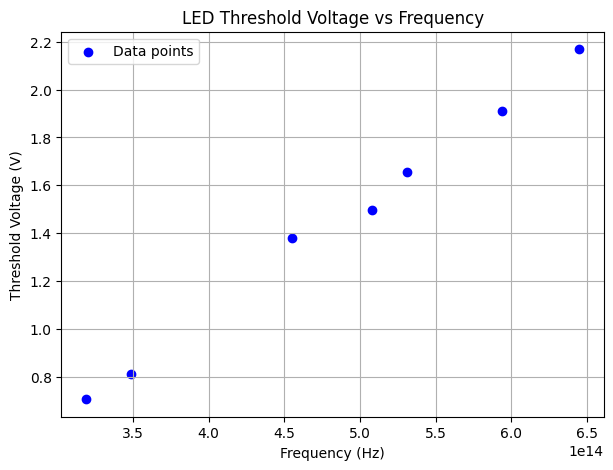

In [7]:
# Step 4: Plot raw data
plt.figure(figsize=(7,5))
plt.scatter(df['Frequency (Hz)'], df['Measured Voltage (V)'], color='blue', label='Data points')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Threshold Voltage (V)')
plt.title('LED Threshold Voltage vs Frequency')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Step 5: Linear regression (Vth = (h/q) * f + intercept)
slope, intercept, r_value, p_value, std_err = linregress(df['Frequency (Hz)'], df['Measured Voltage (V)'])

# Step 6: Compute Planck's constant
q = 1.602e-19  # C
h_measured = slope * q
h_true = 6.626e-34
percent_error = abs((h_measured - h_true) / h_true) * 100

print(f"Slope (h/q): {slope:.3e} V·s")
print(f"Intercept: {intercept:.3f} V")
print(f"Measured Planck’s constant h = {h_measured:.3e} J·s")
print(f"Accepted value of h = {h_true:.3e} J·s")
print(f"Percent error = {percent_error:.2f}%")
print(f"R² = {r_value**2:.4f}")

Slope (h/q): 4.460e-15 V·s
Intercept: -0.720 V
Measured Planck’s constant h = 7.145e-34 J·s
Accepted value of h = 6.626e-34 J·s
Percent error = 7.84%
R² = 0.9951


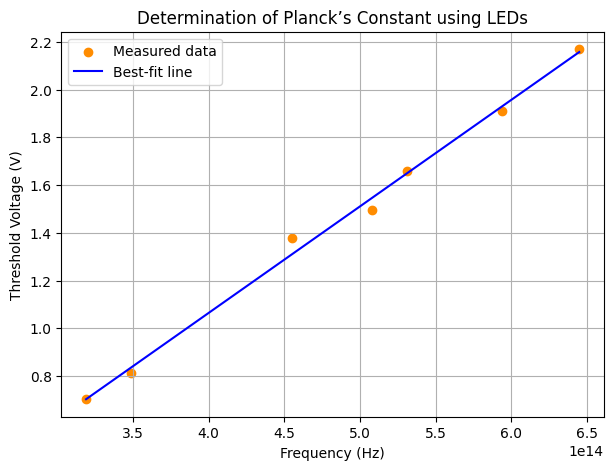

In [19]:
# Step 7: Plot best-fit line
plt.figure(figsize=(7,5))
plt.scatter(df['Frequency (Hz)'], df['Measured Voltage (V)'], color='darkorange', label='Measured data')
plt.plot(df['Frequency (Hz)'], intercept + slope * df['Frequency (Hz)'], color='blue', label='Best-fit line')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Threshold Voltage (V)")
plt.title("Determination of Planck’s Constant using LEDs")
plt.legend()
plt.grid(True)
plt.show()